# Detecting Argmaxable and Unargmaxable Classes

This notebook collects the code and figures for the LP part of the project. The main question is simple: if we fix a weight matrix $W$, which classes can really become the argmax of the linear classifier, and which classes can never win?

I use two LP formulations for this question. I first work with one two-dimensional example because the geometry is easy to draw. After that I check the two LPs on small test cases and on random matrices.

## 1. Core LP routines and a small random baseline

I start with the bounded max-min LP used in the report. For one target class, the LP finds the largest common margin against all other classes inside a box $[-z_{box}, z_{box}]^d$.

If the best margin is positive, I call that class argmaxable. The short random experiment at the end of this section is only a first check. Later sections give a more careful validation.

In [1]:
import numpy as np
from scipy.optimize import linprog
from time import time


def solve_margin_lp(W, cstar, z_box=100.0, raise_on_fail=False):
    n, d = W.shape
    w_star = W[cstar]

    # variables are z and t
    c_obj = np.zeros(d + 1)
    c_obj[-1] = -1.0

    A = []
    b = []

    # one inequality for each other class
    for c in range(n):
        if c == cstar:
            continue

        row = np.zeros(d + 1)
        row[:d] = W[c] - w_star
        row[-1] = 1.0
        A.append(row)
        b.append(0.0)

    # keep z in a box so the LP stays bounded
    bounds = [(-z_box, z_box)] * d + [(None, None)]
    res = linprog(
        c=c_obj,
        A_ub=np.array(A),
        b_ub=np.array(b),
        bounds=bounds,
        method="highs",
    )

    if not res.success:
        if raise_on_fail:
            raise RuntimeError(f"LP failed for class {cstar}: {res.message}")
        return None

    return res


def margin_lp_for_class(W, cstar, z_box=100.0):
    res = solve_margin_lp(W, cstar, z_box=z_box)
    if res is None:
        return None
    return res.x[-1]


def argmaxable_classes(W, tol=1e-6, z_box=100.0):
    # class is argmaxable if the best margin is positive
    n, _ = W.shape
    is_arg = np.zeros(n, dtype=bool)

    for cstar in range(n):
        t_star = margin_lp_for_class(W, cstar, z_box=z_box)
        if t_star is not None and t_star > tol:
            is_arg[cstar] = True

    return is_arg


def run_experiment(n_list, d_list, trials=5, seed=42, z_box=100.0):
    # quick random test
    rng = np.random.default_rng(seed)

    for n in n_list:
        for d in d_list:
            fractions = []
            start = time()

            for _ in range(trials):
                W = rng.standard_normal((n, d))
                is_arg = argmaxable_classes(W, z_box=z_box)
                fractions.append(is_arg.mean())

            elapsed = time() - start

            print("=" * 60)
            print(f"n = {n}, d = {d}, n/d = {n/d:.2f}")
            print(f"Mean argmaxable fraction: {np.mean(fractions):.4f}")
            print(f"Std over trials: {np.std(fractions):.4f}")
            print(f"Time: {elapsed:.2f}s")

The next cell runs the basic random experiment. It gives a first feeling for how the argmaxable fraction changes when the number of classes and the feature dimension change.

In [2]:
# simple sizes for the first experiment
n_list = [10, 20, 40, 80]
d_list = [2, 4, 8, 16]

run_experiment(n_list, d_list, trials=3)

n = 10, d = 2, n/d = 5.00
Mean argmaxable fraction: 0.6333
Std over trials: 0.0943
Time: 0.02s
n = 10, d = 4, n/d = 2.50
Mean argmaxable fraction: 1.0000
Std over trials: 0.0000
Time: 0.01s
n = 10, d = 8, n/d = 1.25
Mean argmaxable fraction: 1.0000
Std over trials: 0.0000
Time: 0.02s
n = 10, d = 16, n/d = 0.62
Mean argmaxable fraction: 1.0000
Std over trials: 0.0000
Time: 0.02s
n = 20, d = 2, n/d = 10.00
Mean argmaxable fraction: 0.3000
Std over trials: 0.0408
Time: 0.03s
n = 20, d = 4, n/d = 5.00
Mean argmaxable fraction: 0.8333
Std over trials: 0.0850
Time: 0.03s
n = 20, d = 8, n/d = 2.50
Mean argmaxable fraction: 1.0000
Std over trials: 0.0000
Time: 0.03s
n = 20, d = 16, n/d = 1.25
Mean argmaxable fraction: 1.0000
Std over trials: 0.0000
Time: 0.03s


n = 40, d = 2, n/d = 20.00
Mean argmaxable fraction: 0.1667
Std over trials: 0.0312
Time: 0.06s
n = 40, d = 4, n/d = 10.00
Mean argmaxable fraction: 0.6167
Std over trials: 0.0624
Time: 0.06s
n = 40, d = 8, n/d = 5.00
Mean argmaxable fraction: 1.0000
Std over trials: 0.0000
Time: 0.07s


n = 40, d = 16, n/d = 2.50
Mean argmaxable fraction: 1.0000
Std over trials: 0.0000
Time: 0.08s
n = 80, d = 2, n/d = 40.00
Mean argmaxable fraction: 0.0958
Std over trials: 0.0059
Time: 0.14s


n = 80, d = 4, n/d = 20.00
Mean argmaxable fraction: 0.4333
Std over trials: 0.0156
Time: 0.15s
n = 80, d = 8, n/d = 10.00
Mean argmaxable fraction: 0.9458
Std over trials: 0.0257
Time: 0.17s


n = 80, d = 16, n/d = 5.00
Mean argmaxable fraction: 1.0000
Std over trials: 0.0000
Time: 0.20s


## 2. A concrete two-dimensional example

From here on I use one fixed matrix $W$ with four rows in $\mathbb{R}^2$. Because the feature space has dimension $2$, the feasible sets can be drawn directly.

I split the helper code into small groups. This makes it easier to see which functions are only for setup, which functions build the feasible regions, and which functions only make the final plots.

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# example used in the plots below
W = np.array([
    [-0.8, -0.8],   # c1
    [ 0.4,  1.2],   # c2
    [ 0.8, -0.4],   # c3
    [ 0.4,  0.1],   # c4
])

class_names = ["c1", "c2", "c3", "c4"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

def draw_weight_vectors(ax, W, class_names, colors, arrow_scale=1.0):
    # draw the rows of W as arrows
    for i, w in enumerate(W):
        ax.arrow(
            0, 0, arrow_scale * w[0], arrow_scale * w[1],
            head_width=0.08, head_length=0.10,
            length_includes_head=True,
            color=colors[i], linewidth=2.0,
        )
        ax.text(
            arrow_scale * w[0] + 0.05,
            arrow_scale * w[1] + 0.05,
            class_names[i],
            color=colors[i], fontsize=10,
        )
    ax.scatter(0, 0, color="black", s=25, zorder=5)

def style_axis(ax, x_min, x_max, y_min, y_max):
    ax.grid(True, which="both", linestyle=":", linewidth=0.8, alpha=0.8)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    ax.set_xlabel("$z_1$")
    ax.set_ylabel("$z_2$")

The next helper cell builds the basic geometry in the $(z_1, z_2)$ plane.

These functions do the following:

- make a grid of points in the plane,
- check which points satisfy all class inequalities for a fixed target class,
- solve the two-dimensional max-margin LP,
- draw one threshold line at a time.

I keep these low-level helpers separate from the final plotting functions below.

In [4]:
def margin_region_mask(W, target_idx, threshold, Z, grid_shape):
    # check which grid points satisfy all inequalities
    wt = W[target_idx]
    mask = np.ones(Z.shape[0], dtype=bool)

    for i in range(W.shape[0]):
        if i == target_idx:
            continue
        mask &= (Z @ (wt - W[i]) >= threshold)

    return mask.reshape(grid_shape)

def solve_margin_lp_2d(W, target_idx, z_box=1.0):
    # return the best z and the best t
    res = solve_margin_lp(W, target_idx, z_box=z_box, raise_on_fail=True)
    z_star = res.x[:W.shape[1]]
    t_star = res.x[-1]
    return z_star, t_star, res

def make_grid(x_min=-5, x_max=5, y_min=-5, y_max=5, n_grid=501):
    # make a grid for the plots
    z1 = np.linspace(x_min, x_max, n_grid)
    z2 = np.linspace(y_min, y_max, n_grid)
    Z1, Z2 = np.meshgrid(z1, z2)
    Z = np.stack([Z1.ravel(), Z2.ravel()], axis=1)
    return Z1, Z2, Z

def plot_threshold_boundary(ax, a, threshold, x_min, x_max, color,
                            linestyle="--", linewidth=1.8, alpha=0.9):
    if abs(a[1]) > 1e-12:
        xx = np.linspace(x_min, x_max, 400)
        yy = (threshold - a[0] * xx) / a[1]
        ax.plot(xx, yy, linestyle, color=color, linewidth=linewidth, alpha=alpha)
    elif abs(a[0]) > 1e-12:
        x0 = threshold / a[0]
        ax.axvline(x=x0, linestyle=linestyle, color=color, linewidth=linewidth, alpha=alpha)

These two functions use the helpers above to make the first main pictures.

- `print_zbox_results` prints the optimal margin for each class for several box sizes,
- `plot_feasibility_regions_for_all_classes` draws the fixed-margin feasible region for each target class.

This is the first place where the LP becomes visible as geometry.

In [5]:
def print_zbox_results(W, z_box_values):
    print("Optimal LP solutions for different z_box values:\n")
    for z_box in z_box_values:
        print(f"===== z_box = {z_box} =====")
        for target_idx in range(W.shape[0]):
            z_star, t_star, _ = solve_margin_lp_2d(W, target_idx, z_box=z_box)
            print(
                f"Target {class_names[target_idx]}: "
                f"z* = ({z_star[0]: .4f}, {z_star[1]: .4f}), "
                f"t* = {t_star: .6f}"
            )
        print()

def plot_feasibility_regions_for_all_classes(W, epsilon=0.5, plot_limit=3.0, n_grid=501):
    n_classes = W.shape[0]
    ncols = 2
    nrows = int(np.ceil(n_classes / ncols))
    x_min, x_max = -plot_limit, plot_limit
    y_min, y_max = -plot_limit, plot_limit
    Z1, Z2, Z = make_grid(x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max, n_grid=n_grid)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(5.2 * ncols, 4.8 * nrows),
        squeeze=False,
    )
    axes = axes.ravel()

    for target_idx, ax in enumerate(axes[:n_classes]):
        wt = W[target_idx]
        mask = margin_region_mask(W, target_idx, epsilon, Z, Z1.shape)
        status = "feasible" if mask.any() else "empty"

        ax.set_axisbelow(True)
        ax.contourf(
            Z1, Z2, mask.astype(float),
            levels=[-0.1, 0.5, 1.1],
            colors=["white", "lightcoral"],
            alpha=0.55,
        )

        for i in range(W.shape[0]):
            if i == target_idx:
                continue
            a = wt - W[i]
            plot_threshold_boundary(ax, a, epsilon, x_min, x_max, colors[i])

        draw_weight_vectors(ax, W, class_names, colors)
        style_axis(ax, x_min, x_max, y_min, y_max)
        ax.text(
            0.03, 0.95, status,
            transform=ax.transAxes,
            va="top",
            fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
        )
        ax.set_title(
            f"target={class_names[target_idx]}, epsilon={epsilon:.2f}\n"
            f"{status} region"
        )

    for ax in axes[n_classes:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Now I run those functions on the example matrix. The printed table shows how the optimal margin changes with the box size, and the figure shows the fixed-margin feasible sets for all four classes.

Optimal LP solutions for different z_box values:

===== z_box = 0.5 =====
Target c1: z* = (-0.5000, -0.5000), t* =  1.000000
Target c2: z* = ( 0.5000,  0.5000), t* =  0.550000
Target c3: z* = ( 0.5000, -0.5000), t* =  0.450000
Target c4: z* = (-0.0000, -0.0000), t* = -0.000000

===== z_box = 1.0 =====
Target c1: z* = (-1.0000, -1.0000), t* =  2.000000
Target c2: z* = ( 1.0000,  1.0000), t* =  1.100000
Target c3: z* = ( 1.0000, -1.0000), t* =  0.900000
Target c4: z* = (-0.0000, -0.0000), t* = -0.000000

===== z_box = 2.0 =====
Target c1: z* = (-2.0000, -2.0000), t* =  4.000000
Target c2: z* = ( 2.0000,  2.0000), t* =  2.200000
Target c3: z* = ( 2.0000, -2.0000), t* =  1.800000
Target c4: z* = (-0.0000, -0.0000), t* = -0.000000

===== z_box = 4.0 =====
Target c1: z* = (-4.0000, -4.0000), t* =  8.000000
Target c2: z* = ( 4.0000,  4.0000), t* =  4.400000
Target c3: z* = ( 4.0000, -4.0000), t* =  3.600000
Target c4: z* = (-0.0000, -0.0000), t* = -0.000000



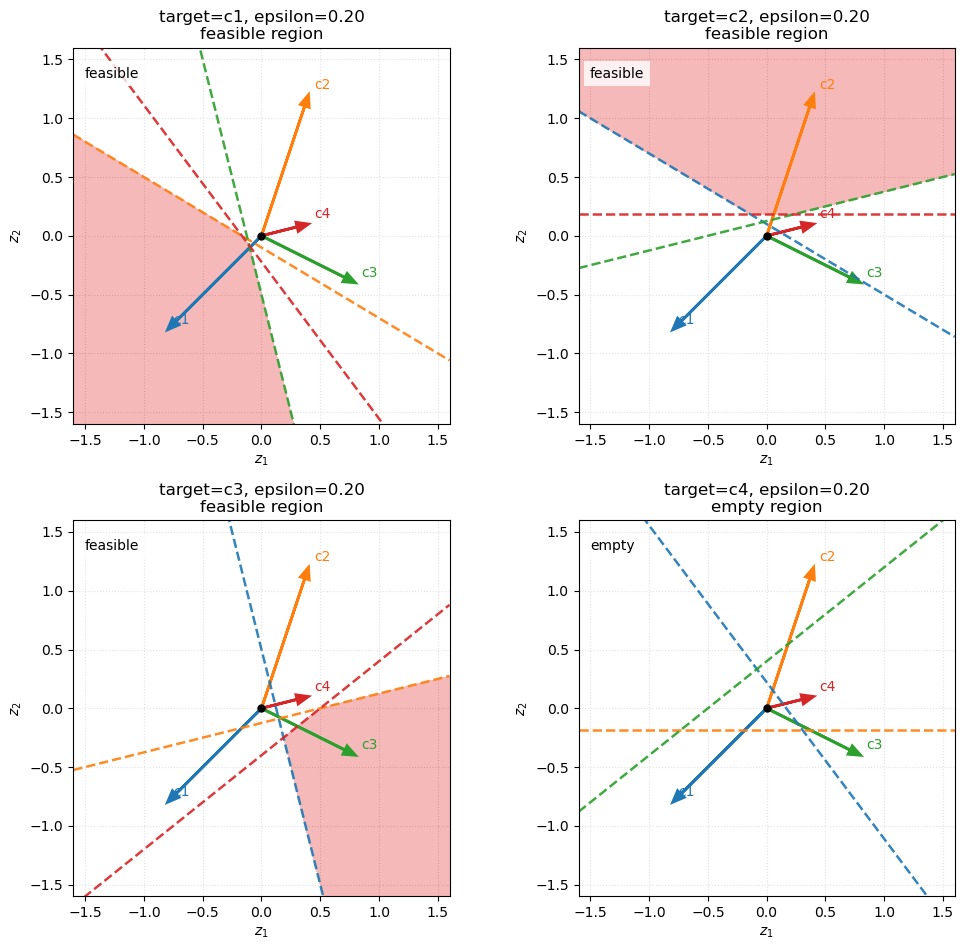

In [6]:
z_box_values = [0.5, 1.0, 2.0, 4.0]

print_zbox_results(W, z_box_values)
plot_feasibility_regions_for_all_classes(W, epsilon=0.2, plot_limit=1.6)

The next helper cell switches from feature space to weight space.

Here I draw the rows of $W$ themselves, compute their convex hull, and normalize the rows to a common radius. This is useful for the normalization discussion later in the report.

In [7]:
def convex_hull_vertices(points):
    pts = np.asarray(points, dtype=float)
    if len(pts) <= 1:
        return pts

    order = np.lexsort((pts[:, 1], pts[:, 0]))
    pts = pts[order]

    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(tuple(p))

    upper = []
    for p in pts[::-1]:
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(tuple(p))

    hull = np.array(lower[:-1] + upper[:-1])
    return hull

def draw_convex_hull(ax, points, color="black", fill_color="lightgray"):
    # The convex hull is shown only as a geometric guide for the row vectors.
    hull = convex_hull_vertices(points)
    if len(hull) == 0:
        return hull

    hull_closed = np.vstack([hull, hull[0]])
    ax.fill(
        hull_closed[:, 0],
        hull_closed[:, 1],
        color=fill_color,
        alpha=0.12,
        zorder=0,
    )
    ax.plot(
        hull_closed[:, 0],
        hull_closed[:, 1],
        color=color,
        linestyle="-.",
        linewidth=1.8,
        alpha=0.9,
        zorder=3,
    )
    return hull

def normalize_rows_to_radius(W, radius=1.0):
    norms = np.linalg.norm(W, axis=1, keepdims=True)
    return radius * W / norms

def draw_weight_space_vectors(ax, W, class_names, colors, plot_limit):
    head_width = 0.04 * plot_limit
    head_length = 0.06 * plot_limit
    text_offset = 0.05 * plot_limit

    for i, w in enumerate(W):
        ax.arrow(
            0,
            0,
            w[0],
            w[1],
            head_width=head_width,
            head_length=head_length,
            length_includes_head=True,
            color=colors[i],
            linewidth=2.2,
            zorder=4,
        )
        ax.text(
            w[0] + text_offset,
            w[1] + text_offset,
            class_names[i],
            color=colors[i],
            fontsize=10,
            weight="bold",
            zorder=5,
        )

    ax.scatter(0, 0, color="black", s=25, zorder=6)

def style_weight_axis(ax, plot_limit):
    ax.grid(True, which="both", linestyle=":", linewidth=0.8, alpha=0.8)
    ax.set_xlim(-plot_limit, plot_limit)
    ax.set_ylim(-plot_limit, plot_limit)
    ax.set_aspect("equal")
    ax.set_xlabel("$w_1$")
    ax.set_ylabel("$w_2$")

This plotting function combines those weight-space helpers into one side-by-side comparison: the original rows of W on the left, and the row-normalized version on the right.

In [8]:
def plot_equal_norm_comparison(W, radius=1.0, original_limit=3.4, normalized_limit=1.25):
    W_normalized = normalize_rows_to_radius(W, radius=radius)

    fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.4), squeeze=False)
    axes = axes.ravel()
    configs = [
        (
            axes[0],
            W,
            original_limit,
            None,
            "Original weight geometry\n$w_4$ lies inside the convex hull",
        ),
        (
            axes[1],
            W_normalized,
            normalized_limit,
            radius,
            "Equal-norm reparameterisation\nall rows lie on a common circle",
        ),
    ]

    for ax, weights, plot_limit, circle_radius, title in configs:
        ax.set_axisbelow(True)
        draw_convex_hull(ax, weights)

        if circle_radius is not None:
            theta = np.linspace(0.0, 2.0 * np.pi, 500)
            ax.plot(
                circle_radius * np.cos(theta),
                circle_radius * np.sin(theta),
                color="black",
                linestyle=":",
                linewidth=1.4,
                zorder=2,
            )

        draw_weight_space_vectors(ax, weights, class_names, colors, plot_limit)
        style_weight_axis(ax, plot_limit)
        ax.set_title(title, fontsize=12)

    plt.tight_layout()
    plt.show()

The next cell draws that comparison plot for the fixed example.

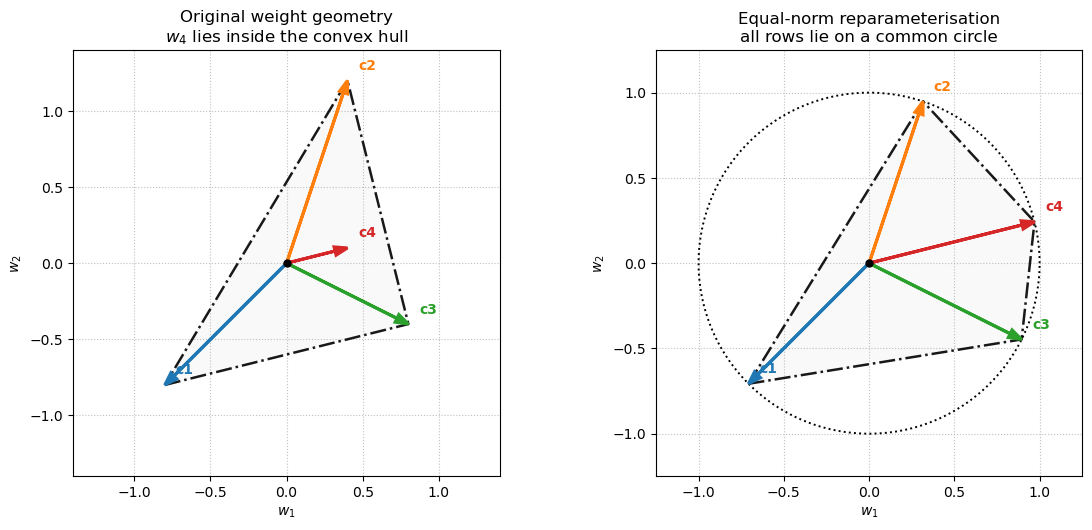

In [9]:
plot_equal_norm_comparison(W, radius=1.0, original_limit=1.4, normalized_limit=1.25)

The next two helper cells make two more summary plots.

The first one shows how the picture changes when the box size changes. The second one shows the feasible set at the optimal value $t^*$ for each class. I keep them separate because they answer two different questions.

In [10]:
def plot_effect_of_zbox(W, z_box_values, plot_limit=5.0, n_grid=501):
    n_classes = W.shape[0]
    n_cols = len(z_box_values)
    x_min, x_max = -plot_limit, plot_limit
    y_min, y_max = -plot_limit, plot_limit
    Z1, Z2, Z = make_grid(x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max, n_grid=n_grid)

    fig, axes = plt.subplots(
        n_classes,
        n_cols,
        figsize=(4.8 * n_cols, 4.6 * n_classes),
        squeeze=False,
    )

    for row, target_idx in enumerate(range(n_classes)):
        wt = W[target_idx]

        for col, z_box in enumerate(z_box_values):
            ax = axes[row, col]
            z_star, t_star, _ = solve_margin_lp_2d(W, target_idx, z_box=z_box)
            mask = margin_region_mask(W, target_idx, t_star, Z, Z1.shape)

            ax.set_axisbelow(True)
            ax.contourf(
                Z1, Z2, mask.astype(float),
                levels=[-0.1, 0.5, 1.1],
                colors=["white", "lightcoral"],
                alpha=0.55,
            )

            for i in range(W.shape[0]):
                if i == target_idx:
                    continue
                a = wt - W[i]
                slack = a @ z_star - t_star
                active = np.isclose(slack, 0.0, atol=1e-8)
                plot_threshold_boundary(
                    ax,
                    a,
                    t_star,
                    x_min,
                    x_max,
                    colors[i],
                    linestyle="-" if active else "--",
                    linewidth=3.0 if active else 1.8,
                    alpha=1.0 if active else 0.9,
                )

            ax.plot(
                [-z_box, z_box, z_box, -z_box, -z_box],
                [-z_box, -z_box, z_box, z_box, -z_box],
                color="black", linewidth=1.2,
            )
            if mask.sum() <= 1:
                ax.scatter(z_star[0], z_star[1], color="lightcoral", s=140, alpha=0.85, zorder=4)
            ax.scatter(z_star[0], z_star[1], color="black", s=55, zorder=5)
            ax.text(z_star[0] + 0.05, z_star[1] + 0.05, r"$z^\star$", fontsize=11)

            draw_weight_vectors(ax, W, class_names, colors)
            style_axis(ax, x_min, x_max, y_min, y_max)

            ax.set_title(
                f"target={class_names[target_idx]}, box={z_box}\n"
                f"$t^*={t_star:.3f}$, $z^*=({z_star[0]:.2f},{z_star[1]:.2f})$"
            )

    plt.tight_layout()
    plt.show()

In [11]:
def plot_all_classes_optimal_margin(W, z_box=1.0, plot_limit=1.6, n_grid=501):
    n_classes = W.shape[0]
    ncols = 2
    nrows = int(np.ceil(n_classes / ncols))
    x_min, x_max = -plot_limit, plot_limit
    y_min, y_max = -plot_limit, plot_limit
    Z1, Z2, Z = make_grid(x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max, n_grid=n_grid)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(5.2 * ncols, 4.8 * nrows),
        squeeze=False,
    )
    axes = axes.ravel()

    for target_idx, ax in enumerate(axes[:n_classes]):
        wt = W[target_idx]
        z_star, t_star, _ = solve_margin_lp_2d(W, target_idx, z_box=z_box)
        mask = margin_region_mask(W, target_idx, t_star, Z, Z1.shape)

        ax.set_axisbelow(True)
        ax.contourf(
            Z1, Z2, mask.astype(float),
            levels=[-0.1, 0.5, 1.1],
            colors=["white", "lightcoral"],
            alpha=0.55,
        )

        for i in range(W.shape[0]):
            if i == target_idx:
                continue
            a = wt - W[i]
            slack = a @ z_star - t_star
            active = np.isclose(slack, 0.0, atol=1e-8)
            plot_threshold_boundary(
                ax,
                a,
                t_star,
                x_min,
                x_max,
                colors[i],
                linestyle="-" if active else "--",
                linewidth=3.0 if active else 1.8,
                alpha=1.0 if active else 0.9,
            )

        ax.plot(
            [-z_box, z_box, z_box, -z_box, -z_box],
            [-z_box, -z_box, z_box, z_box, -z_box],
            color="black", linewidth=1.2,
        )
        if mask.sum() <= 1:
            ax.scatter(z_star[0], z_star[1], color="lightcoral", s=140, alpha=0.85, zorder=4)
        ax.scatter(z_star[0], z_star[1], color="black", s=55, zorder=5)
        ax.text(z_star[0] + 0.05, z_star[1] + 0.05, r"$z^\star$", fontsize=11)

        draw_weight_vectors(ax, W, class_names, colors)
        style_axis(ax, x_min, x_max, y_min, y_max)
        ax.set_title(
            f"target={class_names[target_idx]}, box={z_box}\n"
            f"$t^*={t_star:.3f}$, $z^*=({z_star[0]:.2f},{z_star[1]:.2f})$"
        )

    for ax in axes[n_classes:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Now I run those two summary plots on the same example matrix.

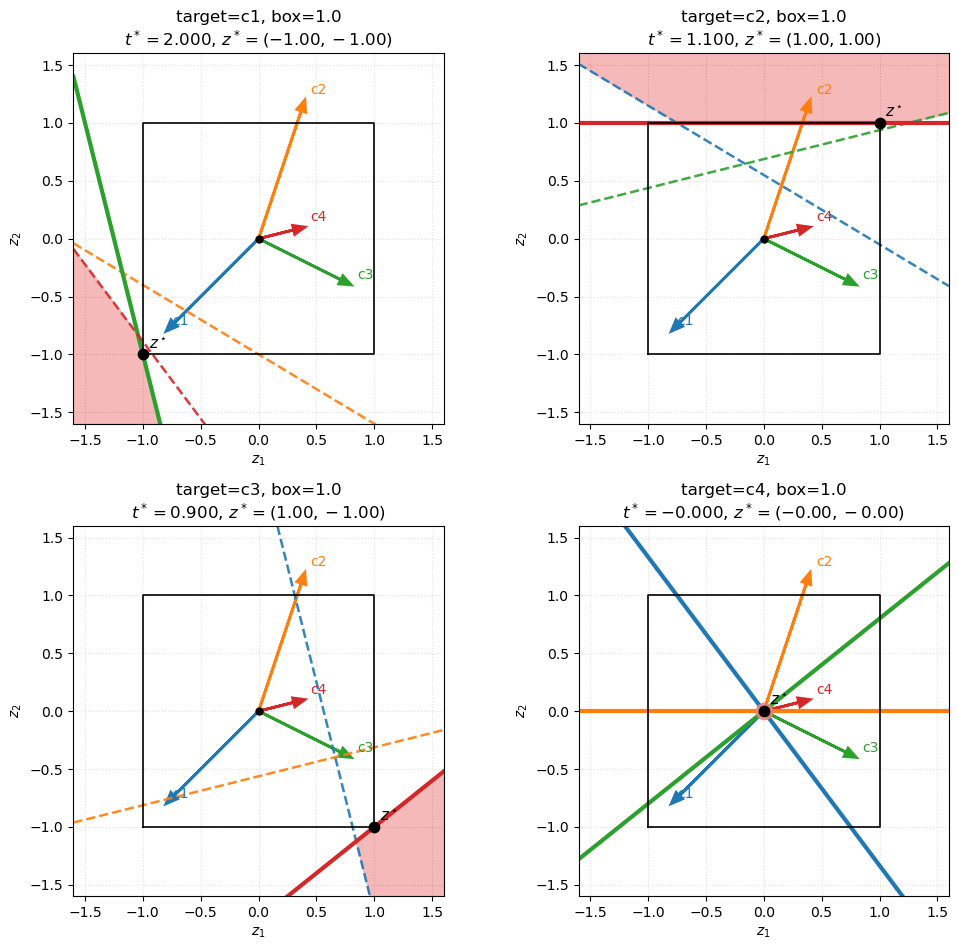

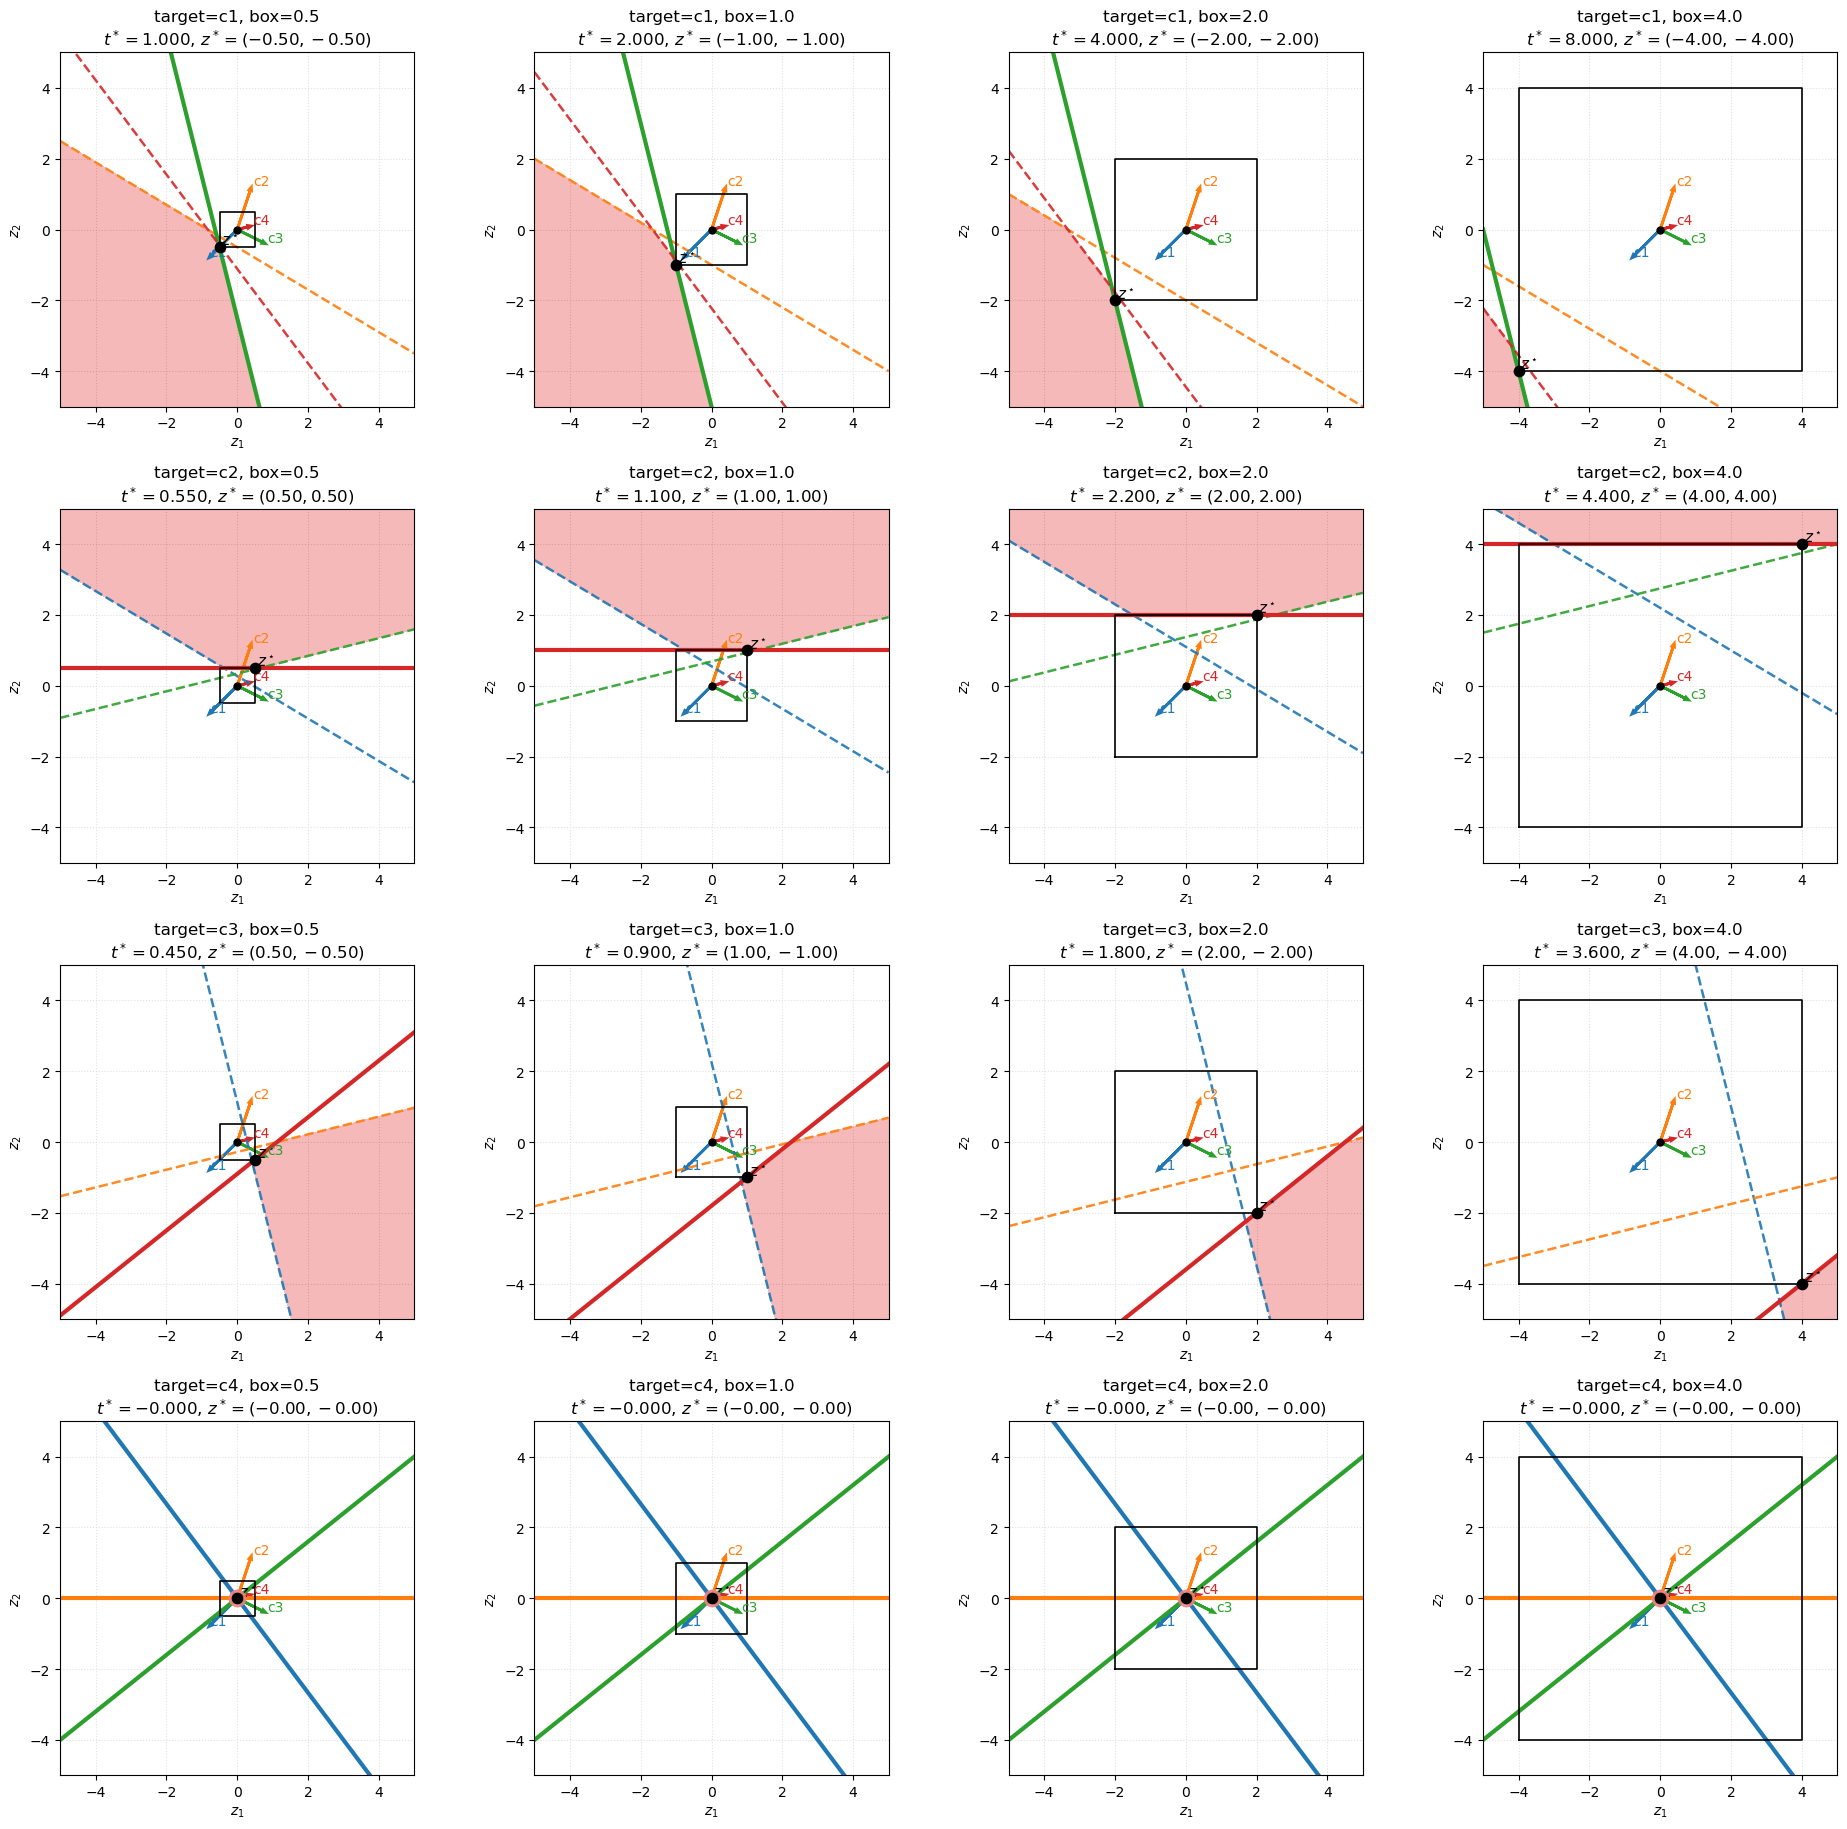

In [12]:
plot_all_classes_optimal_margin(W, z_box=1.0, plot_limit=1.6)
plot_effect_of_zbox(W, z_box_values=z_box_values, plot_limit=5.0)

## 3. Threshold sweep for one target class

In the report, one figure shows how the feasible set shrinks as the required margin $t$ gets larger. The helper below makes that plot for one chosen target class.

I keep it in its own small cell because it is used only once.

In [13]:
def plot_t_trend_for_target(W, target_idx, z_box=1.0, t_values=None,
                            plot_limit=1.6, n_grid=501):
    z_star, t_star, _ = solve_margin_lp_2d(W, target_idx, z_box=z_box)

    if t_values is None:
        t_values = np.linspace(0.0, t_star, 6)

    ncols = 3
    nrows = int(np.ceil(len(t_values) / ncols))
    x_min, x_max = -plot_limit, plot_limit
    y_min, y_max = -plot_limit, plot_limit
    Z1, Z2, Z = make_grid(x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max, n_grid=n_grid)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(5.2 * ncols, 4.8 * nrows),
        squeeze=False,
    )
    axes = axes.ravel()
    wt = W[target_idx]

    for ax, threshold in zip(axes, t_values):
        mask = margin_region_mask(W, target_idx, threshold, Z, Z1.shape)

        ax.set_axisbelow(True)
        ax.contourf(
            Z1, Z2, mask.astype(float),
            levels=[-0.1, 0.5, 1.1],
            colors=["white", "lightcoral"],
            alpha=0.55,
        )

        for i in range(W.shape[0]):
            if i == target_idx:
                continue
            a = wt - W[i]
            active = np.isclose(a @ z_star, t_star, atol=1e-8) and np.isclose(threshold, t_star, atol=1e-8)
            plot_threshold_boundary(
                ax,
                a,
                threshold,
                x_min,
                x_max,
                colors[i],
                linestyle="-" if active else "--",
                linewidth=3.0 if active else 1.8,
                alpha=1.0 if active else 0.9,
            )

        ax.plot(
            [-z_box, z_box, z_box, -z_box, -z_box],
            [-z_box, -z_box, z_box, z_box, -z_box],
            color="black", linewidth=1.2,
        )
        ax.scatter(z_star[0], z_star[1], color="black", s=55, zorder=5)
        ax.text(z_star[0] + 0.05, z_star[1] + 0.05, r"$z^\star$", fontsize=11)

        draw_weight_vectors(ax, W, class_names, colors)
        style_axis(ax, x_min, x_max, y_min, y_max)
        ax.set_title(f"target={class_names[target_idx]}, box={z_box}\n$t={threshold:.2f}$")

    for ax in axes[len(t_values):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Final LP solution for target {class_names[target_idx]} with z_box={z_box}:")
    print(f"  z* = ({z_star[0]:.4f}, {z_star[1]:.4f})")
    print(f"  t* = {t_star:.4f}")

The next cell makes the threshold-sweep figure for class c2.

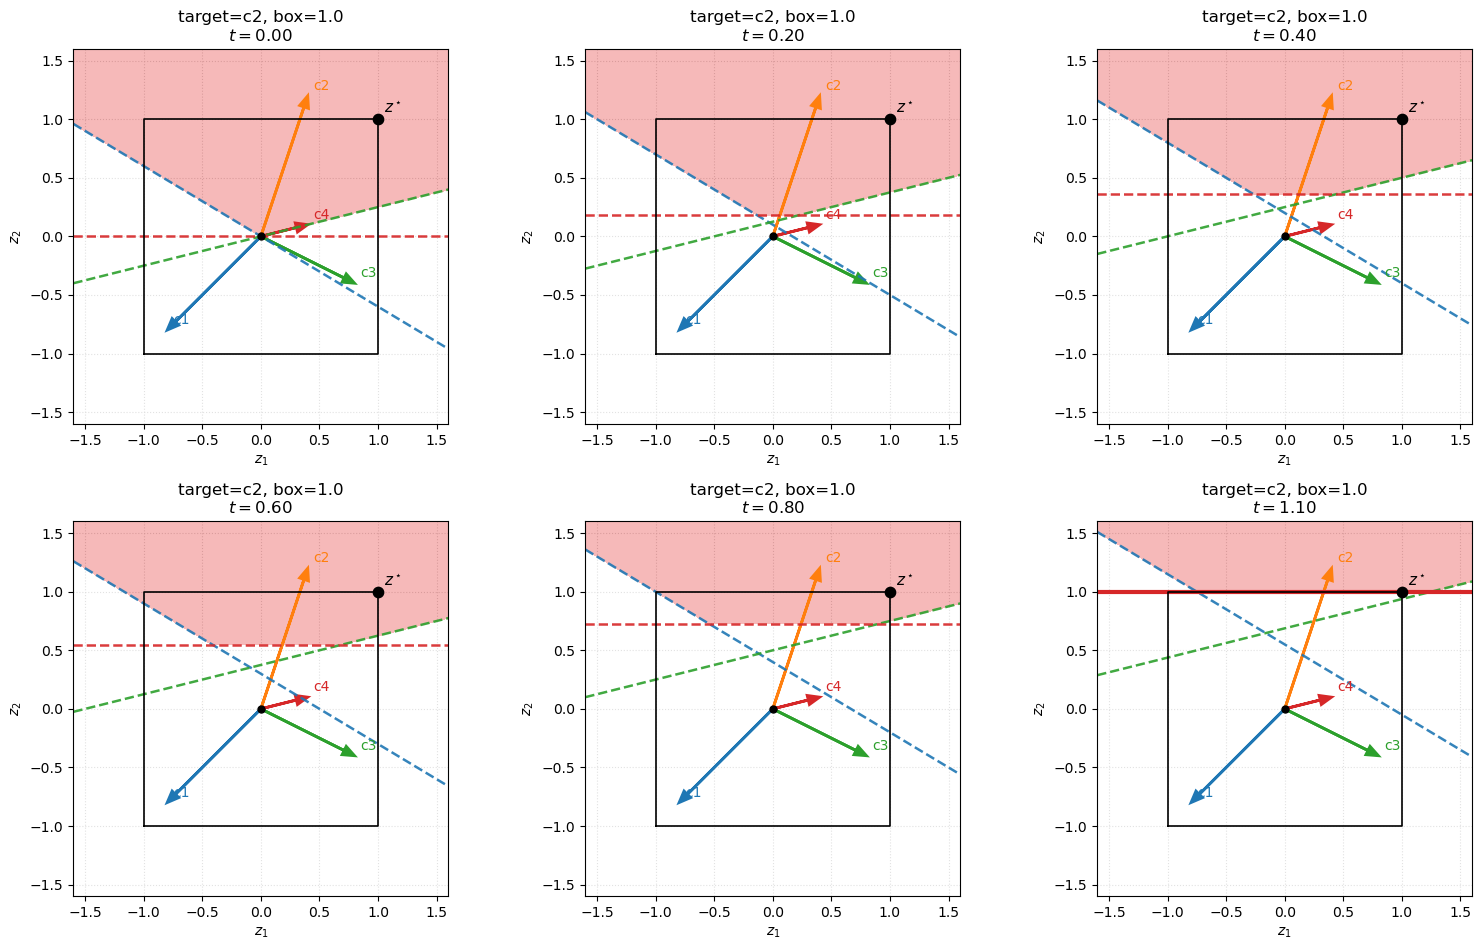

Final LP solution for target c2 with z_box=1.0:
  z* = (1.0000, 1.0000)
  t* = 1.1000


In [14]:
plot_t_trend_for_target(
    W,
    target_idx=1,          # c2
    z_box=1.0,
    t_values=[0.0, 0.2, 0.4, 0.6, 0.8, 1.1],
    plot_limit=1.6,
)

## 4. Deterministic validation cases

Before moving to random matrices, I check a few examples where the correct answer is already known from geometry. This is the easiest way to see whether the implementation is behaving as expected.

I use three cases:

1. triangle vertices: every class should be argmaxable,
2. one point inside the triangle formed by the others: only that inside point should fail,
3. duplicate rows: the duplicate classes should fail because their logits are always the same.

The next cell defines these examples and also gives a small wrapper for the bounded max-min LP.

In [15]:
import cvxpy as cp
import io
from contextlib import redirect_stdout
from time import perf_counter


DETERMINISTIC_CASES = [
    {
        "name": "triangle_vertices",
        "W": np.array([
            [-1.0, -1.0],
            [ 1.0,  0.0],
            [ 0.0,  1.0],
        ]),
        "expected": np.array([True, True, True]),
        "reason": "Every row is a vertex of the triangle formed by the three points.",
    },
    {
        "name": "one_point_inside_hull",
        "W": np.array([
            [-0.8, -0.8],
            [ 0.4,  1.2],
            [ 0.8, -0.4],
            [ 0.4,  0.1],
        ]),
        "expected": np.array([True, True, True, False]),
        "reason": "The fourth row lies inside the triangle formed by the first three.",
    },
    {
        "name": "duplicate_rows",
        "W": np.array([
            [1.0, 0.0],
            [1.0, 0.0],
            [0.0, 1.0],
        ]),
        "expected": np.array([False, False, True]),
        "reason": "The first two classes have identical logits for every z, so neither can be argmaxable.",
    },
]

def format_mask(mask):
    return mask.astype(int)

def max_margin_lp_argmaxable_classes(W, tol=1e-8, z_box=1.0):
    return argmaxable_classes(W, tol=tol, z_box=z_box)

This cell keeps the fixed-margin feasibility LP in almost the same form as before. I only add a small wrapper so that the final output is a Boolean mask, which is easier to compare with the other LP.

In [16]:
def unargm_opt(j, W):
    # feasibility LP for one class
    n, d = W.shape; epsilon = 0.1
    z = cp.Variable(d)
    obj = cp.Minimize(0)
    constraints = [
        (W[i, :] - W[j, :]) @ z <= -epsilon
        for i in range(0, n) if i != j
    ]
    prob = cp.Problem(obj, constraints)
    prob.solve()
    return prob.status

def unargm(W=None, cat=False):
    # run the feasibility LP for every class

    # if no matrix is given, use a small test case
    if W is None: # test
        W = np.array([
            [1, 2],
            [3, 4],
        ])
    n, d = W.shape

    # check the classes one by one
    result = []
    for i in range(0, n):
        wi = W[i, :]
        status = unargm_opt(j=i, W=W)
        if status in ["optimal", "optimal_inaccurate"]:
            out = 0
        else:
            out = 1
        result.append(out)
        print(f"finished {i}")

    if cat:
        print("give result")
    return result

def feasibility_lp_argmaxable_classes(W):
    # True means argmaxable
    with io.StringIO() as buffer, redirect_stdout(buffer):
        raw = unargm(W=W)
    return np.array(raw, dtype=int) == 0

The driver below runs both LPs on each deterministic case and prints the expected answer together with the two computed masks. I use `1` for argmaxable and `0` for unargmaxable in the printed output because it is easier to read side by side.

In [17]:
def run_deterministic_validation(z_box=1.0, tol=1e-8):
    print("Deterministic validation")
    print("-" * 72)

    num_failures = 0

    for case in DETERMINISTIC_CASES:
        W_case = case["W"]
        expected = case["expected"]

        max_margin_mask = max_margin_lp_argmaxable_classes(W_case, tol=tol, z_box=z_box)
        feasibility_mask = feasibility_lp_argmaxable_classes(W_case)

        passed = (
            np.array_equal(max_margin_mask, expected)
            and np.array_equal(feasibility_mask, expected)
            and np.array_equal(max_margin_mask, feasibility_mask)
        )

        print(f"case: {case['name']}")
        print(f"  reason       : {case['reason']}")
        print(f"  expected     : {format_mask(expected)}")
        print(f"  max-margin   : {format_mask(max_margin_mask)}")
        print(f"  feasibility  : {format_mask(feasibility_mask)}")
        print(f"  status       : {'pass' if passed else 'FAIL'}")
        print()

        if not passed:
            num_failures += 1
            print("First mismatch encountered. Stop deterministic validation here.")
            break

    summary = {
        "all_cases_passed": num_failures == 0,
        "num_cases": len(DETERMINISTIC_CASES),
        "num_failures": num_failures,
    }

    print(summary)
    return summary

### Reading the deterministic output

For each named case, the notebook prints four lines:

- the expected mask,
- the mask from the bounded max-min LP,
- the mask from the fixed-margin feasibility LP,
- and a final `pass` or `FAIL`.

If any deterministic case fails, I do not trust the random comparison later.

In [18]:
deterministic_summary = run_deterministic_validation(
    z_box=1.0,
    tol=1e-8,
)

deterministic_summary

Deterministic validation
------------------------------------------------------------------------
case: triangle_vertices
  reason       : Every row is a vertex of the triangle formed by the three points.
  expected     : [1 1 1]
  max-margin   : [1 1 1]
  feasibility  : [1 1 1]
  status       : pass

case: one_point_inside_hull
  reason       : The fourth row lies inside the triangle formed by the first three.
  expected     : [1 1 1 0]
  max-margin   : [1 1 1 0]
  feasibility  : [1 1 1 0]
  status       : pass

case: duplicate_rows
  reason       : The first two classes have identical logits for every z, so neither can be argmaxable.
  expected     : [0 0 1]
  max-margin   : [0 0 1]
  feasibility  : [0 0 1]
  status       : pass

{'all_cases_passed': True, 'num_cases': 3, 'num_failures': 0}


{'all_cases_passed': True, 'num_cases': 3, 'num_failures': 0}

## 5. Random validation of the two LP formulations

Once the deterministic cases pass, I compare the two LPs on random Gaussian matrices. In each trial I sample one matrix $W$, then I send that same matrix to both LP formulations.

This is a consistency check. It does not replace the deterministic cases, but it tells us whether the two implementations keep agreeing when the examples are no longer hand-made.

In [19]:
def run_random_validation(num_random=40, seed=11, z_box=1.0, tol=1e-8):
    rng = np.random.default_rng(seed)

    mismatch_count = 0
    first_counterexample = None

    print("Random validation")
    print("-" * 72)

    for trial in range(num_random):
        n = int(rng.integers(4, 9))
        d = int(rng.integers(2, 6))
        W_trial = rng.standard_normal((n, d))

        max_margin_mask = max_margin_lp_argmaxable_classes(W_trial, tol=tol, z_box=z_box)
        feasibility_mask = feasibility_lp_argmaxable_classes(W_trial)

        if not np.array_equal(max_margin_mask, feasibility_mask):
            mismatch_count += 1
            if first_counterexample is None:
                first_counterexample = {
                    "trial": trial,
                    "n": n,
                    "d": d,
                    "W": W_trial.tolist(),
                    "max_margin_mask": max_margin_mask.astype(int).tolist(),
                    "feasibility_mask": feasibility_mask.astype(int).tolist(),
                }
            print(f"Mismatch on trial {trial}: n={n}, d={d}")
            print(W_trial)
            print(f"  max-margin   : {format_mask(max_margin_mask)}")
            print(f"  feasibility  : {format_mask(feasibility_mask)}")
            print()

    summary = {
        "random_trials": num_random,
        "method_mismatches": mismatch_count,
        "first_counterexample": first_counterexample,
    }

    print(summary)
    return summary

### Reading the random-validation summary

The summary dictionary is short:

- `random_trials` is the number of random matrices tested,
- `method_mismatches` counts how many times the two LPs gave different class masks,
- `first_counterexample` stores the first disagreement if one appears.

If `method_mismatches` is zero, then the two LP formulations agreed on every random matrix in this experiment.

In [20]:
if deterministic_summary["all_cases_passed"]:
    random_validation_summary = run_random_validation(
        num_random=40,
        seed=11,
        z_box=1.0,
        tol=1e-8,
    )
else:
    print("Random validation skipped because the deterministic cases did not all pass.")
    random_validation_summary = None

random_validation_summary

Random validation
------------------------------------------------------------------------


{'random_trials': 40, 'method_mismatches': 0, 'first_counterexample': None}


{'random_trials': 40, 'method_mismatches': 0, 'first_counterexample': None}

## 6. Random matrices with and without the equal-norm constraint

The next experiment asks a different question. Instead of checking whether the two LPs agree, I compare random matrices before and after row normalization.

For each random matrix, I first compute the argmaxable fraction in the original form. Then I normalize every row to a common radius and compute the fraction again. This gives a simple numerical check of the equal-norm idea from the report.

In [21]:
def run_random_constraint_experiment(
    n_list,
    d_list,
    trials=10,
    seed=0,
    z_box=1.0,
    radius=1.0,
    tol=1e-8,
):
    # Each trial uses the same random directions before and after row normalisation.
    rng = np.random.default_rng(seed)
    results = []

    header = (
        f"{'n':>4} {'d':>4} "
        f"{'plain frac':>12} {'equal-norm frac':>18} "
        f"{'plain all':>12} {'equal-norm all':>18}"
    )
    print(header)
    print('-' * len(header))

    for n in n_list:
        for d in d_list:
            plain_fracs = []
            equal_fracs = []
            plain_all = []
            equal_all = []

            for _ in range(trials):
                W_plain = rng.standard_normal((n, d))
                W_equal = normalize_rows_to_radius(W_plain, radius=radius)

                plain_mask = argmaxable_classes(W_plain, tol=tol, z_box=z_box)
                equal_mask = argmaxable_classes(W_equal, tol=tol, z_box=z_box)

                plain_fracs.append(plain_mask.mean())
                equal_fracs.append(equal_mask.mean())
                plain_all.append(float(plain_mask.all()))
                equal_all.append(float(equal_mask.all()))

            row = {
                'n': n,
                'd': d,
                'plain_fraction_mean': float(np.mean(plain_fracs)),
                'plain_fraction_std': float(np.std(plain_fracs)),
                'equal_fraction_mean': float(np.mean(equal_fracs)),
                'equal_fraction_std': float(np.std(equal_fracs)),
                'plain_all_rate': float(np.mean(plain_all)),
                'equal_all_rate': float(np.mean(equal_all)),
            }
            results.append(row)

            print(
                f"{n:4d} {d:4d} "
                f"{row['plain_fraction_mean']:12.4f} {row['equal_fraction_mean']:18.4f} "
                f"{row['plain_all_rate']:12.4f} {row['equal_all_rate']:18.4f}"
            )

    return results

In [22]:
def plot_random_constraint_results(results):
    # Compare average argmaxability and the stronger event that every class is argmaxable.
    labels = [f"n={row['n']}, d={row['d']}" for row in results]
    x = np.arange(len(results))
    width = 0.38

    plain_fraction = [row['plain_fraction_mean'] for row in results]
    equal_fraction = [row['equal_fraction_mean'] for row in results]
    plain_fraction_std = [row['plain_fraction_std'] for row in results]
    equal_fraction_std = [row['equal_fraction_std'] for row in results]

    plain_all = [row['plain_all_rate'] for row in results]
    equal_all = [row['equal_all_rate'] for row in results]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), squeeze=False)
    axes = axes.ravel()

    axes[0].bar(
        x - width / 2,
        plain_fraction,
        width,
        yerr=plain_fraction_std,
        capsize=4,
        label='unconstrained W',
        color='lightcoral',
        alpha=0.85,
    )
    axes[0].bar(
        x + width / 2,
        equal_fraction,
        width,
        yerr=equal_fraction_std,
        capsize=4,
        label='equal-norm W',
        color='steelblue',
        alpha=0.85,
    )
    axes[0].set_ylabel('Mean argmaxable fraction')
    axes[0].set_ylim(0.0, 1.05)
    axes[0].set_title('Fraction of classes that are argmaxable')
    axes[0].grid(True, axis='y', linestyle=':', alpha=0.7)
    axes[0].legend()

    axes[1].bar(
        x - width / 2,
        plain_all,
        width,
        label='unconstrained W',
        color='lightcoral',
        alpha=0.85,
    )
    axes[1].bar(
        x + width / 2,
        equal_all,
        width,
        label='equal-norm W',
        color='steelblue',
        alpha=0.85,
    )
    axes[1].set_ylabel('Rate that all classes are argmaxable')
    axes[1].set_ylim(0.0, 1.05)
    axes[1].set_title('How often every class is argmaxable')
    axes[1].grid(True, axis='y', linestyle=':', alpha=0.7)
    axes[1].legend()

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=35, ha='right')

    plt.tight_layout()
    plt.show()

The next cell runs that experiment and then draws the comparison plot.

   n    d   plain frac    equal-norm frac    plain all     equal-norm all
-------------------------------------------------------------------------
  10    2       0.5375             1.0000       0.0000             1.0000
  10    4       0.9000             1.0000       0.2500             1.0000


  10    8       1.0000             1.0000       1.0000             1.0000
  20    2       0.3375             1.0000       0.0000             1.0000


  20    4       0.8500             1.0000       0.0000             1.0000
  20    8       1.0000             1.0000       1.0000             1.0000


  40    2       0.1781             1.0000       0.0000             1.0000


  40    4       0.6438             1.0000       0.0000             1.0000


  40    8       0.9750             1.0000       0.2500             1.0000


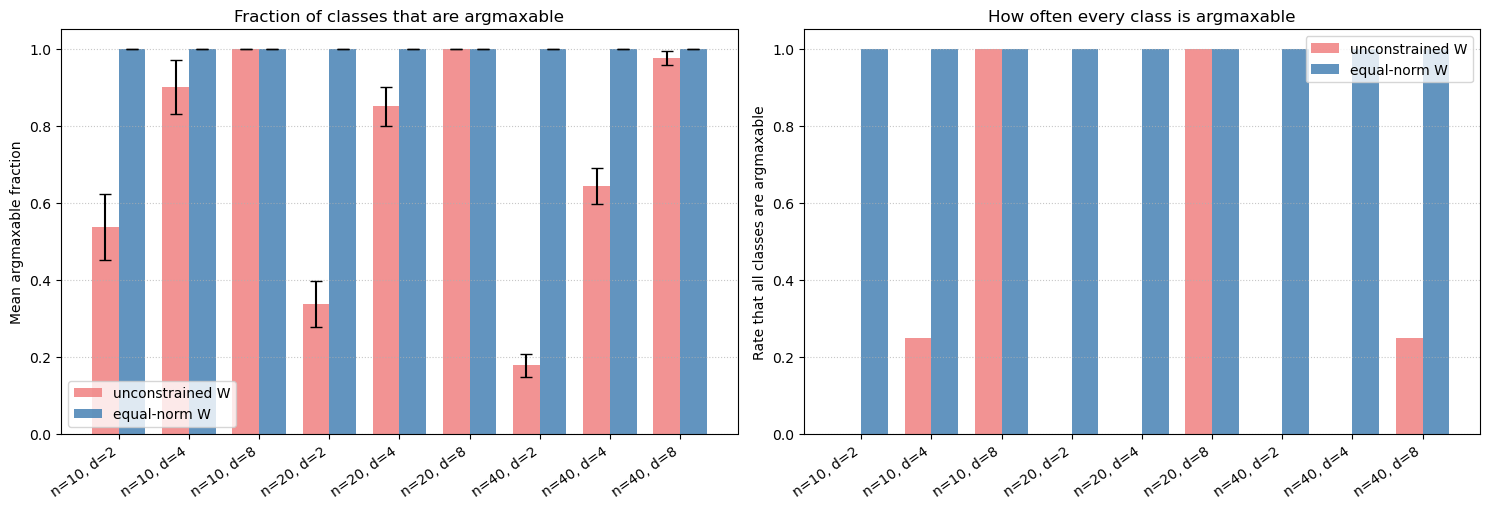

In [23]:
random_results = run_random_constraint_experiment(
    n_list=[10, 20, 40],
    d_list=[2, 4, 8],
    trials=8,
    seed=7,
    z_box=1.0,
    radius=1.0,
)

plot_random_constraint_results(random_results)

## 7. Timing comparison of the two LP formulations

In the last part, I compare the running time of the two LPs. To make the comparison fair, I rewrite both formulations in `cvxpy` and solve them with the same backend solver.

For each pair $(n,d)$, I use the same random matrices for both LPs and randomize the order of the two solves. This way the timing comparison is about the formulations, not about using two different software stacks.

In [24]:
import cvxpy as cp
from time import perf_counter


def solve_margin_lp_cvxpy(W, cstar, z_box=1.0, solver="HIGHS"):
    # same max-margin LP, but written in cvxpy
    n, d = W.shape
    z = cp.Variable(d)
    t = cp.Variable()

    constraints = [z <= z_box, z >= -z_box]
    for c in range(n):
        if c == cstar:
            continue
        constraints.append((W[cstar, :] - W[c, :]) @ z >= t)

    prob = cp.Problem(cp.Maximize(t), constraints)
    prob.solve(solver=solver, verbose=False)
    return prob, z, t

def max_margin_lp_cvxpy_argmaxable_classes(W, tol=1e-8, z_box=1.0, solver="HIGHS"):
    # return True/False for all classes
    n, _ = W.shape
    mask = np.zeros(n, dtype=bool)

    for cstar in range(n):
        prob, _, t = solve_margin_lp_cvxpy(W, cstar, z_box=z_box, solver=solver)
        if prob.status in ["optimal", "optimal_inaccurate"] and t.value is not None and t.value > tol:
            mask[cstar] = True

    return mask

def feasibility_lp_cvxpy_argmaxable_classes(W, epsilon=0.1, solver="HIGHS"):
    # same feasibility LP, also written in cvxpy
    n, d = W.shape
    mask = np.zeros(n, dtype=bool)

    for j in range(n):
        z = cp.Variable(d)
        constraints = [
            (W[i, :] - W[j, :]) @ z <= -epsilon
            for i in range(n) if i != j
        ]
        prob = cp.Problem(cp.Minimize(0), constraints)
        prob.solve(solver=solver, verbose=False)
        mask[j] = prob.status in ["optimal", "optimal_inaccurate"]

    return mask

This helper function runs the timing benchmark itself. It stores the solve time for both LPs on the same random instances.

In [25]:
def benchmark_cvxpy_formulations(
    n_list,
    d_list,
    trials=3,
    seed=19,
    z_box=1.0,
    tol=1e-8,
    epsilon=0.1,
    solver="HIGHS",
):
    # compare the two cvxpy versions on the same random matrices
    rng = np.random.default_rng(seed)
    records = []

    warm_W = np.array([
        [-0.8, -0.8],
        [ 0.4,  1.2],
        [ 0.8, -0.4],
        [ 0.4,  0.1],
    ])
    _ = max_margin_lp_cvxpy_argmaxable_classes(warm_W, tol=tol, z_box=z_box, solver=solver)
    _ = feasibility_lp_cvxpy_argmaxable_classes(warm_W, epsilon=epsilon, solver=solver)

    method_specs = [
        ("max_margin", lambda W: max_margin_lp_cvxpy_argmaxable_classes(W, tol=tol, z_box=z_box, solver=solver)),
        ("feasibility", lambda W: feasibility_lp_cvxpy_argmaxable_classes(W, epsilon=epsilon, solver=solver)),
    ]

    for n in n_list:
        for d in d_list:
            for trial in range(trials):
                W_trial = rng.standard_normal((n, d))
                order = list(method_specs)
                rng.shuffle(order)

                times = {}
                masks = {}

                for method_name, method_fn in order:
                    start = perf_counter()
                    masks[method_name] = method_fn(W_trial)
                    times[method_name] = perf_counter() - start

                records.append({
                    "n": n,
                    "d": d,
                    "trial": trial,
                    "max_margin_time": times["max_margin"],
                    "feasibility_time": times["feasibility"],
                    "masks_match": np.array_equal(masks["max_margin"], masks["feasibility"]),
                })

    return records

These final helper functions summarize the timing results, print a small table, and make the comparison plot.

In [26]:
def summarize_timing_records(records):
    # group the timing results by (n, d)
    grouped = {}
    for rec in records:
        key = (rec["n"], rec["d"])
        grouped.setdefault(key, []).append(rec)

    summary = []
    for (n, d), group in sorted(grouped.items()):
        max_times = np.array([g["max_margin_time"] for g in group])
        feas_times = np.array([g["feasibility_time"] for g in group])
        summary.append({
            "n": n,
            "d": d,
            "trials": len(group),
            "all_masks_match": all(g["masks_match"] for g in group),
            "max_margin_median": float(np.median(max_times)),
            "max_margin_mean": float(np.mean(max_times)),
            "feasibility_median": float(np.median(feas_times)),
            "feasibility_mean": float(np.mean(feas_times)),
            "feasibility_over_max_margin": float(np.median(feas_times) / np.median(max_times)),
        })

    return summary

def print_timing_summary(summary):
    # print a small timing table
    print("Timing comparison (same cvxpy solver)")
    print("-" * 96)
    header = f'{"n":>4} {"d":>4} {"trials":>7} {"max-med (s)":>14} {"feas-med (s)":>15} {"ratio":>9} {"match":>8}'
    print(header)
    print("-" * len(header))

    for row in summary:
        print(
            f'{row["n"]:>4} {row["d"]:>4} {row["trials"]:>7} '
            f'{row["max_margin_median"]:>14.4f} {row["feasibility_median"]:>15.4f} '
            f'{row["feasibility_over_max_margin"]:>9.2f} {str(row["all_masks_match"]):>8}'
        )

def plot_timing_summary(summary):
    # plot the median times
    labels = [f'n={row["n"]}, d={row["d"]}' for row in summary]
    x = np.arange(len(summary))
    max_times = [row["max_margin_median"] for row in summary]
    feas_times = [row["feasibility_median"] for row in summary]

    plt.figure(figsize=(10, 4.8))
    plt.plot(x, max_times, marker="o", linewidth=2.0, label="Bounded max-margin LP")
    plt.plot(x, feas_times, marker="s", linewidth=2.0, label="Fixed-margin feasibility LP")
    plt.xticks(x, labels, rotation=30, ha="right")
    plt.yscale("log")
    plt.ylabel("Median runtime (seconds)")
    plt.title("Timing comparison of the two LPs")
    plt.grid(alpha=0.25, linestyle="--")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

The next cell runs the timing comparison with the same settings used in the report.

Timing comparison (same cvxpy solver)
------------------------------------------------------------------------------------------------
   n    d  trials    max-med (s)    feas-med (s)     ratio    match
-------------------------------------------------------------------
  10    2       3         0.0196          0.0169      0.86     True
  10    4       3         0.0202          0.0171      0.85     True
  10    8       3         0.0196          0.0171      0.87     True
  20    2       3         0.0562          0.0509      0.91     True
  20    4       3         0.0613          0.0658      1.07     True
  20    8       3         0.0616          0.0539      0.88     True
  40    2       3         0.1918          0.1987      1.04     True
  40    4       3         0.2530          0.2281      0.90     True
  40    8       3         0.2324          0.1753      0.75     True


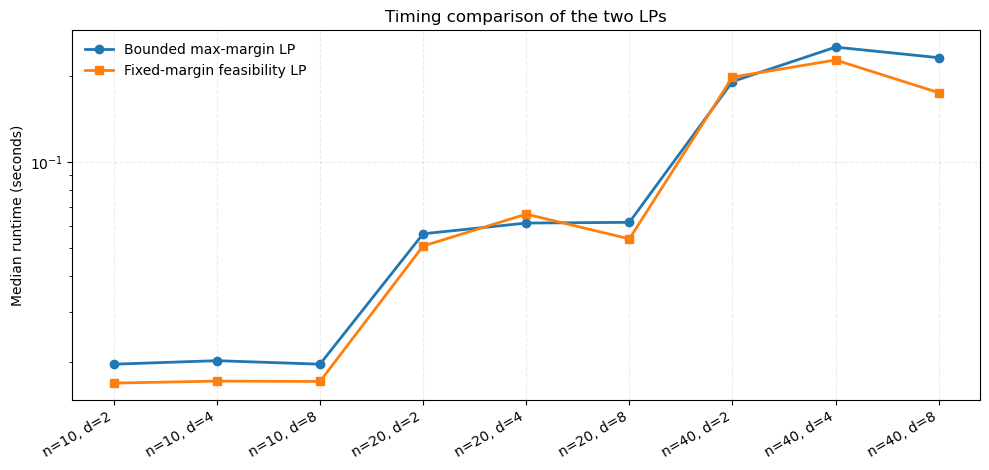

[{'n': 10,
  'd': 2,
  'trials': 3,
  'all_masks_match': True,
  'max_margin_median': 0.019643541891127825,
  'max_margin_mean': 0.019758041637639206,
  'feasibility_median': 0.016866416903212667,
  'feasibility_mean': 0.01684662497912844,
  'feasibility_over_max_margin': 0.8586240198785398},
 {'n': 10,
  'd': 4,
  'trials': 3,
  'all_masks_match': True,
  'max_margin_median': 0.020208499860018492,
  'max_margin_mean': 0.02054216666147113,
  'feasibility_median': 0.017142583150416613,
  'feasibility_mean': 0.017088805713380378,
  'feasibility_over_max_margin': 0.8482857841581976},
 {'n': 10,
  'd': 8,
  'trials': 3,
  'all_masks_match': True,
  'max_margin_median': 0.01964675006456673,
  'max_margin_mean': 0.01973527731994788,
  'feasibility_median': 0.017093374859541655,
  'feasibility_mean': 0.017163833292822044,
  'feasibility_over_max_margin': 0.8700357465416056},
 {'n': 20,
  'd': 2,
  'trials': 3,
  'all_masks_match': True,
  'max_margin_median': 0.05619616690091789,
  'max_margi

In [27]:
timing_records = benchmark_cvxpy_formulations(
    n_list=[10, 20, 40],
    d_list=[2, 4, 8],
    trials=3,
    seed=19,
    z_box=1.0,
    tol=1e-8,
    epsilon=0.1,
    solver="HIGHS",
)

timing_summary = summarize_timing_records(timing_records)
print_timing_summary(timing_summary)
plot_timing_summary(timing_summary)

timing_summary